# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ariq Abdillah Syahlan
- **Email:** ariqabdillahpds@gmail.com
- **ID Dicoding:** ariq_abdillah_7klW

## Menentukan Pertanyaan Bisnis

- Bagaimana kondisi cuaca mempengaruhi ?
- Bagaimana pola penyewaan sepeda harian antara hari kerja dengan hari libur dan pengguna registered dengan casual selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [4]:
# Import library yang digunakan pada proyek
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Data Wrangling

### Gathering Data

In [5]:
# Load data yang diperlukan selama proyek
df_day = pd.read_csv('C:\my data\Kuliah\Dicoding\Project Fundamental Analisis Data\Submission\data\day.csv')
df_hour = pd.read_csv('C:\my data\Kuliah\Dicoding\Project Fundamental Analisis Data\Submission\data\hour.csv')

In [6]:
# Bentuk dataset df_day
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
# Bentuk dataset df_hour
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- memuat dataset yang diperlukan untuk proyek
- dataset mencakup informasi mengenai kondisi pada saat penyewaan sepeda, seperti hari penyewaan, cuaca, hari kerja/libur, suhu, jumlah penyewa, jenis pengguna, dan lainnya.
- perbedaan utama kedua dataset ialah terdapat kolom 'hr' pada df_hour yang merupakan jam pada hari sehingga datanya lebih detail jika dibandingkan dengan df_day

### Assessing Data

#### Data Day

In [8]:
# Cek tipe dan struktur data
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
# Cek missing value
df_day.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
# Cek data duplikat
print("Jumlah data duplikat :", df_day.duplicated().sum())

Jumlah data duplikat : 0


In [11]:
# Cek statistika deskriptif data
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Data terdiri dari 731 baris dan 16 kolom tanpa terdapat missing value dan data duplikat
- Kolom dteday masih bertipe object dan kolom kategorik yang bertipe int64 sebaiknya juga diubah menjadi 'category' agar lebih tepat
- Pada kolom hum (humidity) terdapat nilai minimum 0, ini data yang tidak valid karena hampir tidak mungkin terjadi kelembapan 0%

#### Data Hour

In [12]:
# Cek tipe dan struktur data
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [13]:
# Cek missing value
df_hour.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [14]:
# Cek data duplikat
print("Jumlah data duplikat :", df_hour.duplicated().sum())

Jumlah data duplikat : 0


In [15]:
# Cek statistika deskriptif data
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data terdiri dari 17379 baris dan 17 kolom tanpa terdapat missing value dan data duplikat
- kolom dteday masih bertipe object dan kolom kategorik yang bertipe int64 sebaiknya juga diubah menjadi 'category' agar lebih tepat
- Pada kolom hum (humidity) terdapat nilai minimum 0, ini data yang tidak valid karena hampir tidak mungkin terjadi kelembapan 0%

### Cleaning Data

#### Data Day

In [16]:
# Mengubah format data tanggal menjadi datetime
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

In [17]:
# Mengubah format data kategori menjadi category
categorical_columns = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
df_day[categorical_columns] = df_day[categorical_columns].astype('category')

In [18]:
# Menangani data tidak valid
# Identifikasi baris/tanggal yang tidak valid
date_error_day = df_day[df_day['hum'] == 0]['dteday'].unique()
print(f"Tanggal bermasalah: {date_error_day}")

Tanggal bermasalah: <DatetimeArray>
['2011-03-10 00:00:00']
Length: 1, dtype: datetime64[ns]


In [19]:
# Drop data dengan nilai tidak valid
df_day  = df_day[~df_day['dteday'].isin(date_error_day)]

In [20]:
# Pengecekan kembali
df_day.info()

<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     730 non-null    int64         
 1   dteday      730 non-null    datetime64[ns]
 2   season      730 non-null    category      
 3   yr          730 non-null    category      
 4   mnth        730 non-null    category      
 5   holiday     730 non-null    category      
 6   weekday     730 non-null    category      
 7   workingday  730 non-null    category      
 8   weathersit  730 non-null    category      
 9   temp        730 non-null    float64       
 10  atemp       730 non-null    float64       
 11  hum         730 non-null    float64       
 12  windspeed   730 non-null    float64       
 13  casual      730 non-null    int64         
 14  registered  730 non-null    int64         
 15  cnt         730 non-null    int64         
dtypes: category(7), datetime64[ns](

**Insight:**
- Perubahan tipe data pada python agar lebih sesuai dengan tipe yang sebenarnya
- Penanganan data tidak valid dengan menghapus data

#### Data Hour

In [21]:
# Mengubah format data tanggal menjadi datetime
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

In [22]:
# Mengubah format data kategori menjadi category
categorical_columns = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
df_hour[categorical_columns] = df_hour[categorical_columns].astype('category')

In [23]:
# Menangani data tidak valid
# Identifikasi baris/tanggal yang tidak valid
date_error_hour = df_hour[df_hour['hum'] == 0]['dteday'].unique()
print(f"Tanggal bermasalah: {date_error_hour}")

Tanggal bermasalah: <DatetimeArray>
['2011-03-10 00:00:00']
Length: 1, dtype: datetime64[ns]


In [24]:
# Drop data dengan nilai tidak valid
df_hour  = df_hour[~df_hour['dteday'].isin(date_error_hour)]

In [25]:
# Pengecekan kembali
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17357 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17357 non-null  int64         
 1   dteday      17357 non-null  datetime64[ns]
 2   season      17357 non-null  category      
 3   yr          17357 non-null  category      
 4   mnth        17357 non-null  category      
 5   hr          17357 non-null  int64         
 6   holiday     17357 non-null  category      
 7   weekday     17357 non-null  category      
 8   workingday  17357 non-null  category      
 9   weathersit  17357 non-null  category      
 10  temp        17357 non-null  float64       
 11  atemp       17357 non-null  float64       
 12  hum         17357 non-null  float64       
 13  windspeed   17357 non-null  float64       
 14  casual      17357 non-null  int64         
 15  registered  17357 non-null  int64         
 16  cnt         17357 non-null 

## Exploratory Data Analysis (EDA)

### Explore Data Day

In [26]:
# Melihat distribusi kondisi cuaca
df_day['weathersit'].value_counts()

weathersit
1    463
2    247
3     20
Name: count, dtype: int64

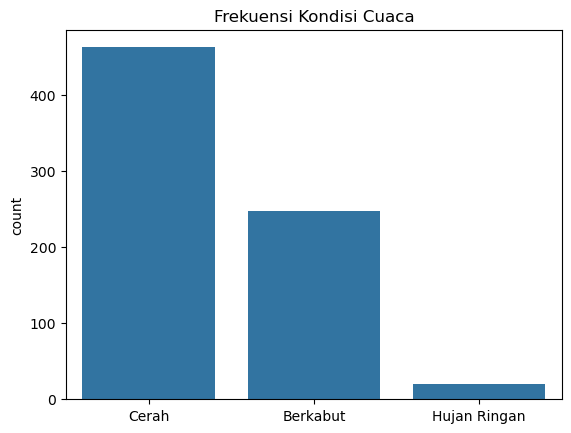

In [27]:
# Bar chart frekuensi kondisi cuaca
weather_labels = {
    1: 'Cerah',
    2: 'Berkabut',
    3: 'Hujan Ringan'
}

df_day['weathersit_label'] = df_day['weathersit'].map(weather_labels)

sns.countplot(x='weathersit_label', data=df_day,
              order=['Cerah', 'Berkabut', 'Hujan Ringan'])
plt.title('Frekuensi Kondisi Cuaca')
plt.xlabel('')
plt.show()

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\490190879.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_count_per_weathersit = df_day.groupby('weathersit')['cnt'].mean().reset_index()


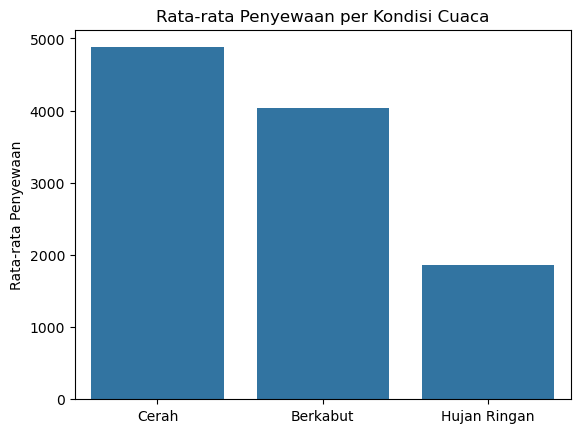

In [28]:
# Bar chart rata-rata penyewaan berdasarkan kondisi cuaca
## Menghitung rata-rata
avg_count_per_weathersit = df_day.groupby('weathersit')['cnt'].mean().reset_index()
avg_count_per_weathersit['weathersit_label'] = avg_count_per_weathersit['weathersit'].map(weather_labels)

## Visualisasi
sns.barplot(x='weathersit_label', y='cnt', data=avg_count_per_weathersit,
            order=['Cerah', 'Berkabut', 'Hujan Ringan'])
plt.title('Rata-rata Penyewaan per Kondisi Cuaca')
plt.xlabel('')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

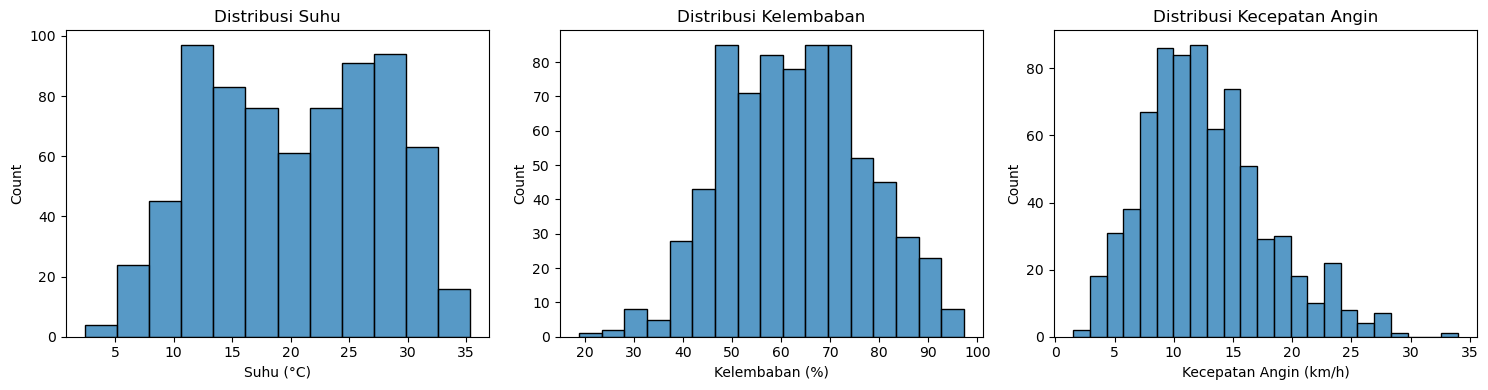

In [29]:
# Bar chart setiap variabel pengaruh kondisi cuaca yang telah dinormalisasi dengan penyewaan

## Denormalisasi
df_day['temp_actual'] = df_day['temp'] * 41        # °C
df_day['hum_actual'] = df_day['hum'] * 100         # %
df_day['windspeed_actual'] = df_day['windspeed'] * 67  # km/h

## Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

### Suhu
sns.histplot(df_day['temp_actual'], ax=axes[0])
axes[0].set_title('Distribusi Suhu')
axes[0].set_xlabel('Suhu (°C)')

### Kelembapan
sns.histplot(df_day['hum_actual'], ax=axes[1])
axes[1].set_title('Distribusi Kelembaban')
axes[1].set_xlabel('Kelembaban (%)')

### Kecepatan angin
sns.histplot(df_day['windspeed_actual'], ax=axes[2])
axes[2].set_title('Distribusi Kecepatan Angin')
axes[2].set_xlabel('Kecepatan Angin (km/h)')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Korelasi Variabel Cuaca dengan penyewaan')

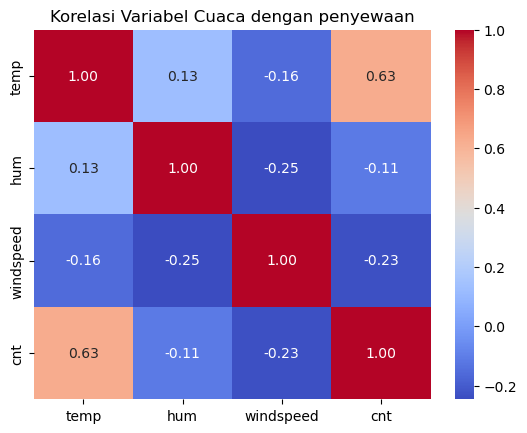

In [30]:
# Korelasi variabel cuaca dengan penyewaan
weather_cols = ['temp', 'hum', 'windspeed', 'cnt']
sns.heatmap(df_day[weather_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Variabel Cuaca dengan penyewaan')

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\1230030639.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly = df_day.groupby(['yr_label', 'mnth'])['cnt'].mean().reset_index()


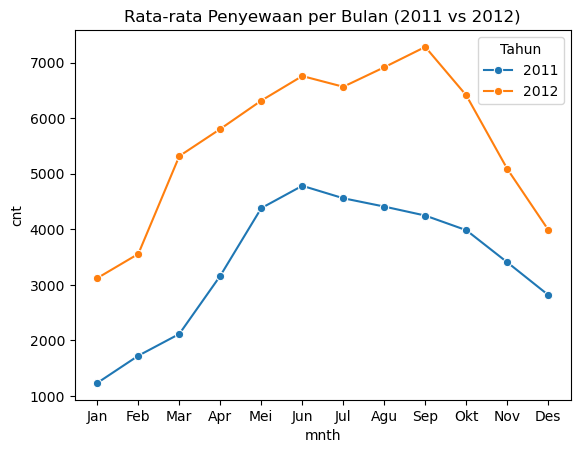

In [31]:
# Line chart tren bulanan antara tahun 2011 vs 2012
df_day['yr_label'] = df_day['yr'].map({0: '2011', 1: '2012'})

monthly = df_day.groupby(['yr_label', 'mnth'])['cnt'].mean().reset_index()

sns.lineplot(x='mnth', y='cnt', hue='yr_label', data=monthly, marker='o')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','Mei','Jun',
                          'Jul','Agu','Sep','Okt','Nov','Des'])
plt.title('Rata-rata Penyewaan per Bulan (2011 vs 2012)')
plt.legend(title='Tahun')
plt.show()

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\1294773901.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_avg = df_day.groupby('weekday')['cnt'].mean().reset_index()


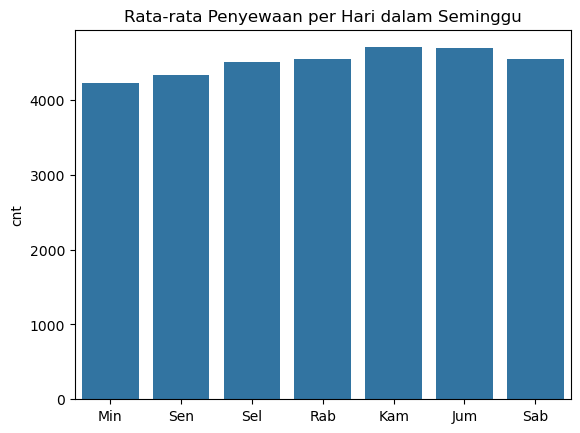

In [32]:
# Bar chart rata-rata penyewaan per hari dalam seminggu
## Menghitung rata-rata
daily_avg = df_day.groupby('weekday')['cnt'].mean().reset_index()

## Visualisasi per hari dalam seminggu
sns.barplot(x='weekday', y='cnt', data=daily_avg, errorbar=None)
plt.xticks(range(7), ['Min','Sen','Sel','Rab','Kam','Jum','Sab'])
plt.title('Rata-rata Penyewaan per Hari dalam Seminggu')
plt.xlabel('')
plt.show()

**Insight:**
- Rata-rata frekuensi penyewaan sepeda lebih banyak ketika cuaca cerah mendekati 5000, kemudian berkabut yang sedikit di atas 4000 lalu terakhir hujan ringan sedikti di bawah 2000
- Terdapat peningkatan jumlah sewa pada tahun 2012 dibandingkan tahun 2011
- Rata-rata jumlah pengguna sepeda cenderung sama setiap harinya dalam seminggu, yaitu sedikit di atas 4000


### Explore Data Hour

In [33]:
# Melihat distribusi kondisi cuaca
df_hour['weathersit'].value_counts()

weathersit
1    11413
2     4542
3     1399
4        3
Name: count, dtype: int64

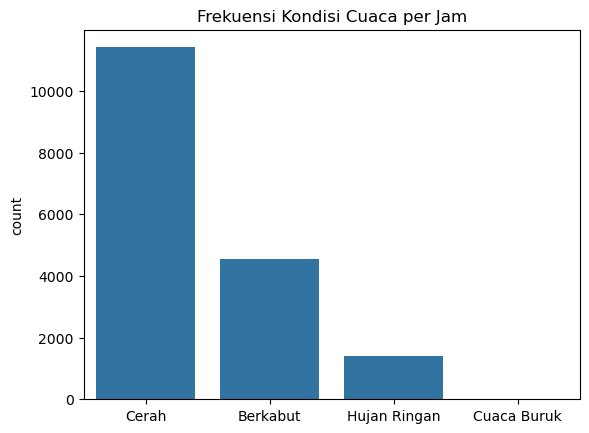

In [34]:
# Bar chart frekuensi kondisi cuaca (per jam)
weather_labels_hour = {
    1: 'Cerah',
    2: 'Berkabut',
    3: 'Hujan Ringan',
    4: 'Cuaca Buruk'
}

df_hour['weathersit_label'] = df_hour['weathersit'].map(weather_labels_hour)

sns.countplot(x='weathersit_label', data=df_hour,
              order=['Cerah', 'Berkabut', 'Hujan Ringan', 'Cuaca Buruk'])
plt.title('Frekuensi Kondisi Cuaca per Jam')
plt.xlabel('')
plt.show()

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\602367935.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_count_per_weathersit_hour = df_hour.groupby('weathersit')['cnt'].mean().reset_index()


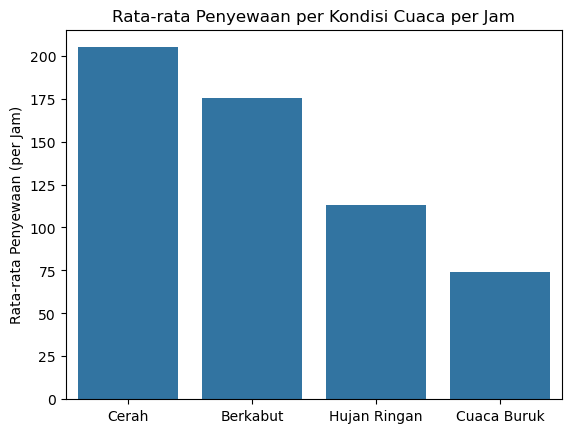

In [35]:
# Bar chart rata-rata penyewaan berdasarkan kondisi cuaca (per jam)
## Menghitung rata-rata
avg_count_per_weathersit_hour = df_hour.groupby('weathersit')['cnt'].mean().reset_index()
avg_count_per_weathersit_hour['weathersit_label'] = avg_count_per_weathersit_hour['weathersit'].map(weather_labels_hour)

## Visualisasi
sns.barplot(x='weathersit_label', y='cnt', data=avg_count_per_weathersit_hour,
            order=['Cerah', 'Berkabut', 'Hujan Ringan', 'Cuaca Buruk'])
plt.title('Rata-rata Penyewaan per Kondisi Cuaca per Jam')
plt.xlabel('')
plt.ylabel('Rata-rata Penyewaan (per Jam)')
plt.show()

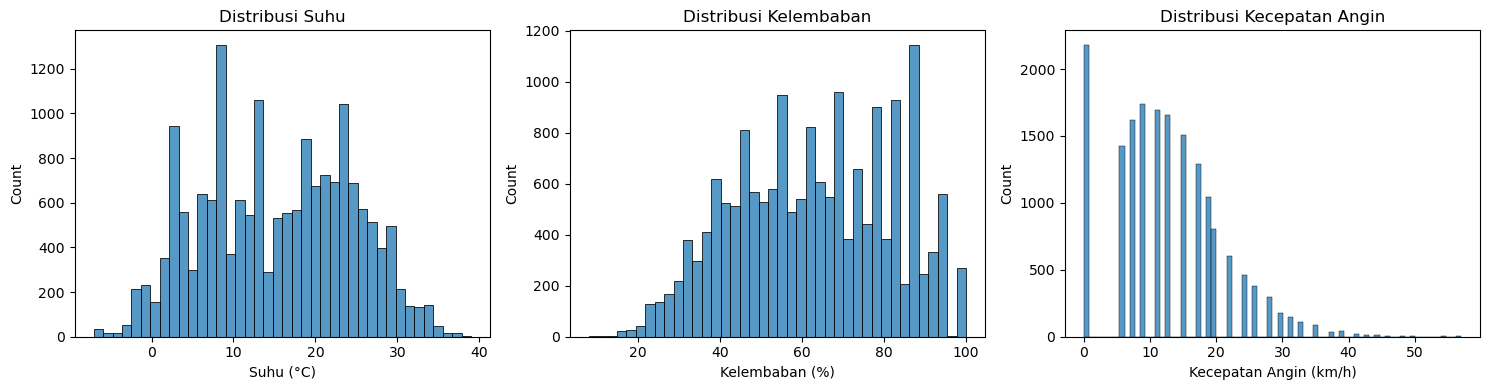

In [36]:
# Bar chart setiap variabel pengaruh kondisi cuaca yang telah dinormalisasi dengan penyewaan (per jam)

## Denormalisasi
df_hour['temp_actual_hour'] = df_hour['temp'] * (39 - (-8)) + (-8)        # °C
df_hour['hum_actual'] = df_hour['hum'] * 100         # %
df_hour['windspeed_actual'] = df_hour['windspeed'] * 67  # km/h

## Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

### Suhu
sns.histplot(df_hour['temp_actual_hour'], ax=axes[0])
axes[0].set_title('Distribusi Suhu')
axes[0].set_xlabel('Suhu (°C)')

### Kelembapan
sns.histplot(df_hour['hum_actual'], ax=axes[1])
axes[1].set_title('Distribusi Kelembaban')
axes[1].set_xlabel('Kelembaban (%)')

### Kecepatan angin
sns.histplot(df_hour['windspeed_actual'], ax=axes[2])
axes[2].set_title('Distribusi Kecepatan Angin')
axes[2].set_xlabel('Kecepatan Angin (km/h)')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Korelasi Variabel Cuaca dengan Penyewaan per Jam')

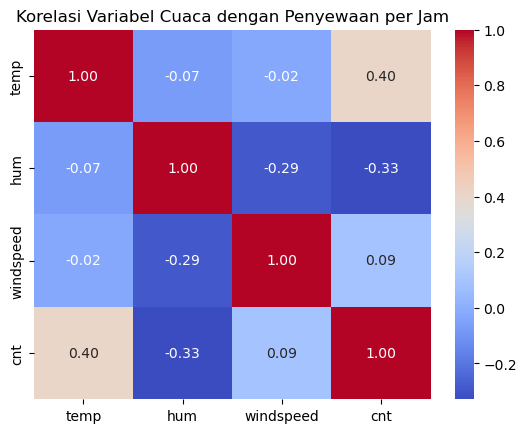

In [37]:
# Korelasi variabel cuaca dengan penyewaan (per jam)
weather_cols = ['temp', 'hum', 'windspeed', 'cnt']
sns.heatmap(df_hour[weather_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Variabel Cuaca dengan Penyewaan per Jam')

**Insight:**
- Rata-rata frekuensi penyewa sepeda lebih banyak ketika cuaca cerah mendekati sekitar 200 per jam


## Visualization & Explanatory Analysis

Pada tahap ini, saya menjawab pertanyaan bisnis yang telah ditentukan dengan menggunakan visualisasi dan temuan yang telah didapat dari proses sebelumnya yaitu Exploratory Data Analysis

### Pertanyaan 1:  Bagaimana kondisi cuaca mempengaruhi ?


C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\648851586.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_count_per_weathersit_hour = df_hour.groupby('weathersit')['cnt'].mean().reset_index()


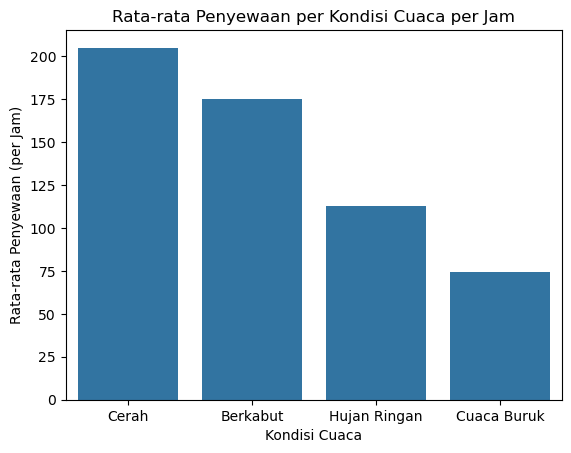

In [38]:
# Bar chart rata-rata penyewaan berdasarkan kondisi cuaca (per jam)
## Menghitung rata-rata
avg_count_per_weathersit_hour = df_hour.groupby('weathersit')['cnt'].mean().reset_index()
avg_count_per_weathersit_hour['weathersit_label'] = avg_count_per_weathersit_hour['weathersit'].map(weather_labels_hour)

## Visualisasi
sns.barplot(x='weathersit_label', y='cnt', data=avg_count_per_weathersit_hour,
            order=['Cerah', 'Berkabut', 'Hujan Ringan', 'Cuaca Buruk'])
plt.title('Rata-rata Penyewaan per Kondisi Cuaca per Jam')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan (per Jam)')
plt.show()

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\1473669336.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hour.groupby(['hr', 'weathersit_label'])['cnt'].mean().unstack().plot(marker='o')


<Figure size 1200x500 with 0 Axes>

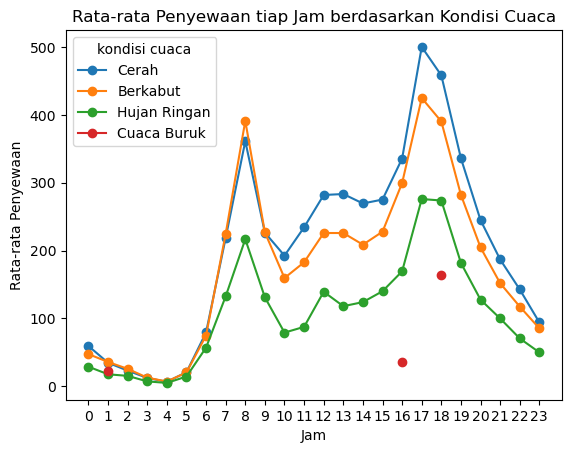

In [39]:
# Line chart rata-rata penyewaan tiap jam berdasarkan kondisi cuaca
plt.figure(figsize=(12, 5))
df_hour.groupby(['hr', 'weathersit_label'])['cnt'].mean().unstack().plot(marker='o')
plt.title('Rata-rata Penyewaan tiap Jam berdasarkan Kondisi Cuaca')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.legend(title='kondisi cuaca')
plt.show()

[Text(0.5, 1.0, 'Kecepatan Angin vs Penyewaan'),
 Text(0.5, 0, 'windspeed'),
 Text(0, 0.5, 'cnt')]

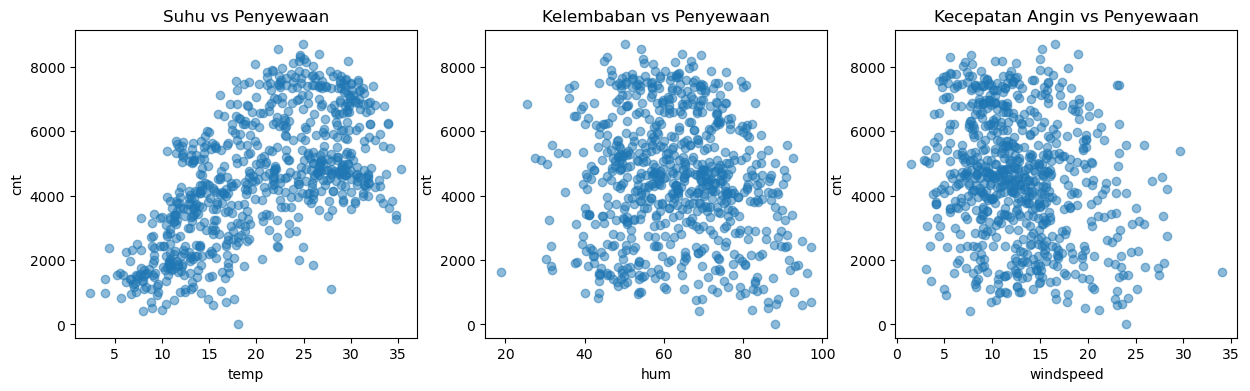

In [40]:
# Scatter plot setiap variabel pengaruh kondisi cuaca yang telah dinormalisasi dengan penyewaan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

## Suhu
axes[0].scatter(df_day['temp_actual'], df_day['cnt'], alpha=0.5)
axes[0].set(title='Suhu vs Penyewaan', xlabel='temp', ylabel='cnt')

## Kelembapan
axes[1].scatter(df_day['hum_actual'], df_day['cnt'], alpha=0.5)
axes[1].set(title='Kelembaban vs Penyewaan', xlabel='hum', ylabel='cnt')

## Kecepatan angin
axes[2].scatter(df_day['windspeed_actual'], df_day['cnt'], alpha=0.5)
axes[2].set(title='Kecepatan Angin vs Penyewaan', xlabel='windspeed', ylabel='cnt')

**Insight:**
- Rata-rata jumlah penyewa sepeda paling banyak adalah ketika cuaca cerah, mencapai sekitar 200 orang per jamnya
- Cuaca cerah cenderung memiliki suhu yang lebih hangat dan juga memiliki kecepatan angin yang tidak terlalu kencang, hal ini didukung dengan hasil korelasi scatter plot suhu dan kecepatan dengan jumlah penyewa sepeda, dari hasil terlihat semakin hangat suhunya semakin banyak pengguna sepeda, kemudian semakin cepat kecepatan angin maka semakin sedikit yang menggunakan sepeda
- Terlihat juga frekuensi penyewaan sepeda tiap jam, di mana dari jam 10 hingga malam hari penyewa sepeda tercatat lebih banyak ketika kondisi cuacanya cerah, memperlihatkan bahwa cuaca cerah berbanding lurus dengan jumlah penyewa sepeda

### Pertanyaan 2:  Bagaimana pola penyewaan sepeda harian antara hari kerja dengan hari libur dan pengguna registered dengan casual selama periode 2011-2012?

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\1741065613.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df_day.groupby('workingday')[['casual', 'registered']].mean()


([<matplotlib.axis.XTick at 0x19d03429310>,
 [Text(0, 0, 'Hari Libur'), Text(1, 0, 'Hari Kerja')])

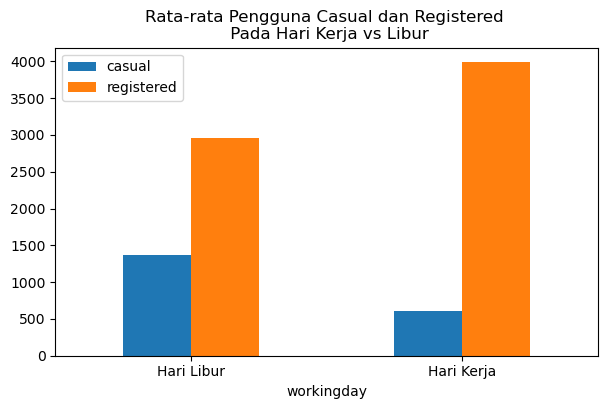

In [41]:
# Bar chart perbandingan rata-rata pengguna casual dan registered berdasarkan hari libur dan hari kerja
seg = df_day.groupby('workingday')[['casual', 'registered']].mean()
seg.plot(kind='bar', figsize=(7, 4))
plt.title('Rata-rata Pengguna Casual dan Registered \n Pada Hari Kerja vs Libur')
plt.xticks([0,1], ['Hari Libur', 'Hari Kerja'], rotation=0)

C:\Users\ariksmen\AppData\Local\Temp\ipykernel_8336\3350984679.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hour.groupby(['hr', 'workingday'])['cnt'].mean().unstack().plot(marker='o')


<Figure size 1200x500 with 0 Axes>

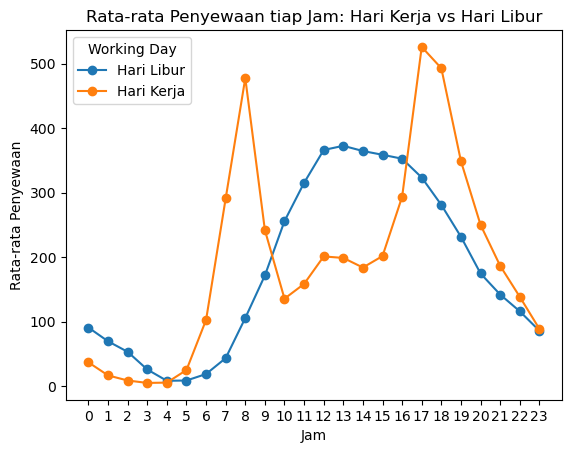

In [42]:
# Line chart rata-rata Penyewaan per jam: hari kerja vs libur
plt.figure(figsize=(12, 5))
df_hour.groupby(['hr', 'workingday'])['cnt'].mean().unstack().plot(marker='o')
plt.title('Rata-rata Penyewaan tiap Jam: Hari Kerja vs Hari Libur')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.legend(title='Working Day', labels=['Hari Libur', 'Hari Kerja'])
plt.show()

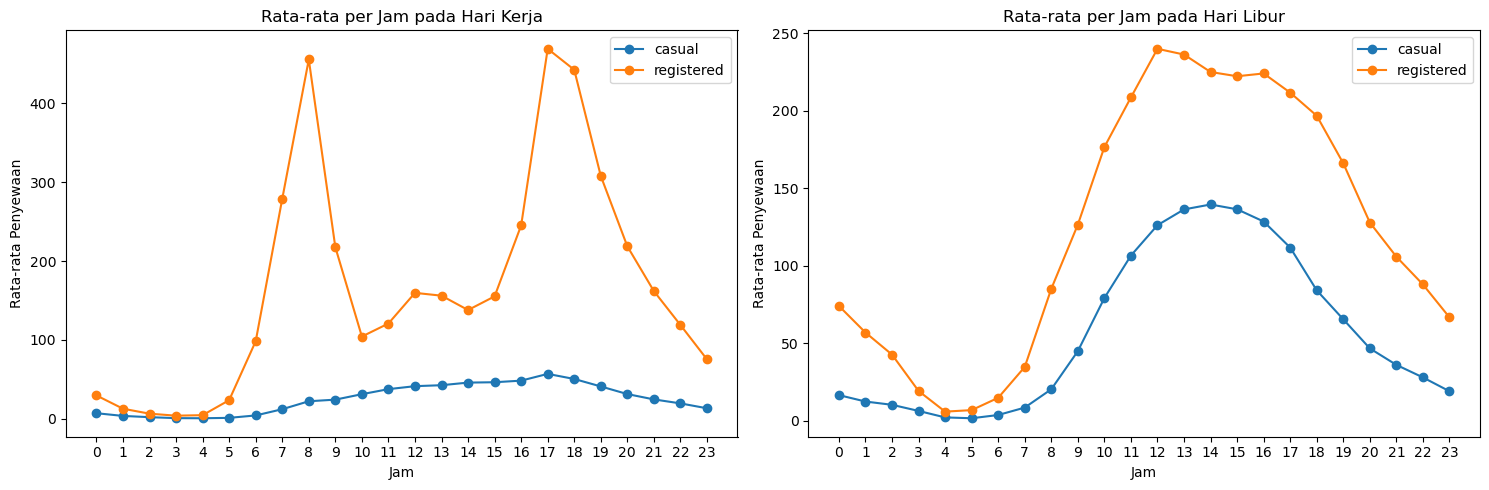

In [43]:
# Line chart perbandingan rata-rata pengguna casual dan Registered tiap jam: hari kerja vs libur
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_hour[df_hour['workingday'] == 1].groupby('hr')[['casual', 'registered']].mean().plot(
    ax=axes[0], marker='o')
axes[0].set_title('Rata-rata per Jam pada Hari Kerja')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata Penyewaan')
axes[0].set_xticks(range(0, 24))

df_hour[df_hour['workingday'] == 0].groupby('hr')[['casual', 'registered']].mean().plot(
    ax=axes[1], marker='o')
axes[1].set_title('Rata-rata per Jam pada Hari Libur')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

**Insight:**
- Jika dilihat dari tren penyewaan sepeda harian, hari kerja sangat dominan diisi oleh pengguna registered dan pada hari libur terdapat penuruna jumlah pengguna registered, tapi juga terdapat kenaikan hampir 2x lipat untuk pengguna casual
- Lalu jika dilihat frekuensi penyewaan sepeda berdasarkan hari kerja dan libur, terlihat 2 pola yang sangat berbeda. Pada hari kerja terdapat 2 puncak aktivitas peminjaman sepeda, yaitu pada pagi hari (jam 7-9) dan sore hingga malam hari (jam 16-20), sementara pada hari libur polanya lebih mirip gunung yang melandai, di mana jumlah penyewa naik sepanjang hari mulai dari jam 8 hingga puncaknya pada jam 12 hingga 16 dan mulai turun kembali hingga jam 20
- Pada pengguna registered dan casual pola terdapat pola yang sangat berbeda pada hari kerja. Pengguna registered memiliki pola yang sama dengan pola harian untuk hari kerja secara umum, sementara untuk pengguna casual lebih mendatar. Lalu pada hari libur pengguna registered dan casual memiliki pola yang mirip dengan pengguna registered masih lebih banyak jika dibandingkan dengan pengguna casual. Akan tetapi terdapat kenaik jumlah yang signifikan pada pengguna casual jika dibandingkan dengan hari kerja.

## Analisis Lanjutan (Opsional)

In [44]:
# Manual Grouping berdasarkan waktu pada hari
def group_time_of_day(hour):
    if 0 <= hour <= 5:
        return 'Dini Hari'
    elif 6 <= hour <= 9:
        return 'Pagi (Rush)'
    elif 10 <= hour <= 14:
        return 'Siang'
    elif 15 <= hour <= 18:
        return 'Sore (Rush)'
    else:
        return 'Malam'

df_hour['time_of_day'] = df_hour['hr'].apply(group_time_of_day)
df_hour['time_of_day'].value_counts()

time_of_day
Dini Hari      4272
Siang          3635
Malam          3635
Sore (Rush)    2913
Pagi (Rush)    2902
Name: count, dtype: int64

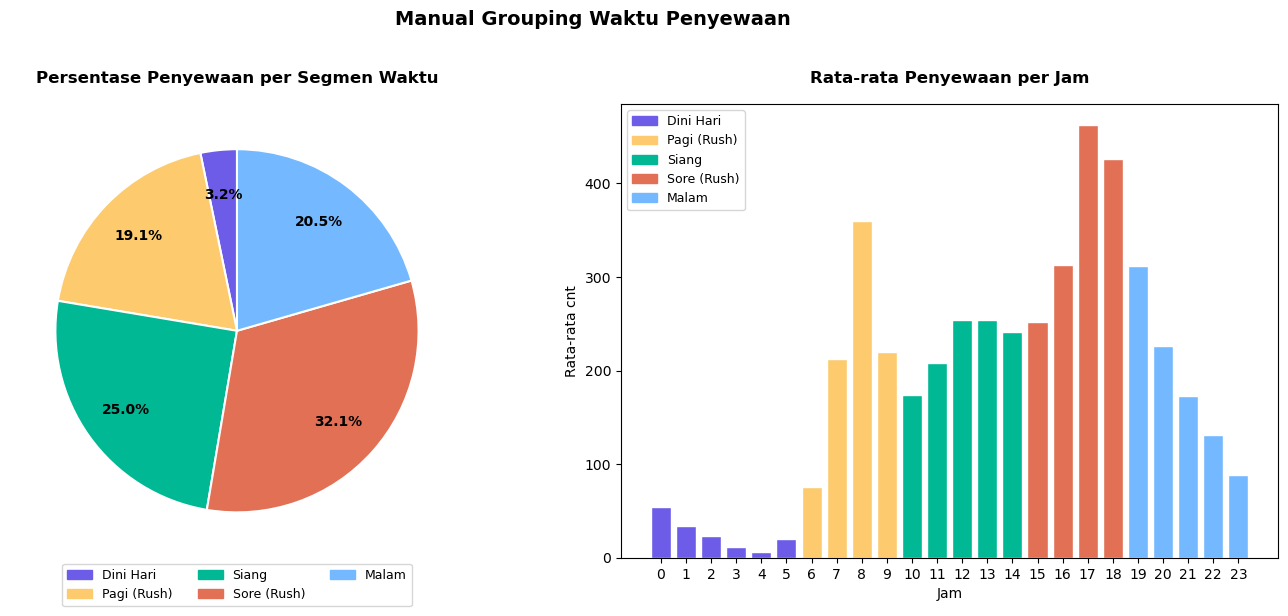

In [46]:
# Visualisasi
order = ['Dini Hari','Pagi (Rush)','Siang','Sore (Rush)','Malam']
order_labels = ['Dini\nHari', 'Pagi\n(Rush)', 'Siang', 'Sore\n(Rush)', 'Malam']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#6C5CE7','#FDCB6E','#00B894','#E17055','#74B9FF']

# Plot PIE CHART persentase total penyewaan berdasarkan pembagian waktu
total_cnt = df_hour.groupby('time_of_day')['cnt'].sum().reindex(order)

wedges, texts, autotexts = axes[0].pie(
    total_cnt.values,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(colors, order)]
axes[0].legend(handles=legend_patches, loc='lower center',
               bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)
axes[0].set_title('Persentase Penyewaan per Segmen Waktu', fontweight='bold', pad=15)


# Plot rata-rata penyewaan per jam
hour_avg = df_hour.groupby('hr')['cnt'].mean()
hour_colors_map = {h: colors[['Dini Hari','Pagi (Rush)','Siang','Sore (Rush)','Malam']
                   .index(group_time_of_day(h))] for h in range(24)}
bar_colors = [hour_colors_map[h] for h in range(24)]
axes[1].bar(range(24), hour_avg.values, color=bar_colors, edgecolor='white')
axes[1].set_xticks(range(24))
axes[1].set_xticklabels(range(24))
axes[1].set_title('Rata-rata Penyewaan per Jam', fontweight='bold', pad=15)
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata cnt')
legend_labels = ['Dini Hari', 'Pagi (Rush)', 'Siang', 'Sore (Rush)', 'Malam']

legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(colors, legend_labels)]
axes[1].legend(handles=legend_patches, loc='upper left', fontsize=9)

plt.suptitle('Manual Grouping Waktu Penyewaan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Dari hasil manual grouping terlihat berdasarkan pembagian manual, waktu dengan frekuensi penyewaan terbanyak ada pada sore hari, juga dapat dilihat pada grafik penyewaan per jam dalam hari bahwa puncak tertinggi penyewaan terjadi pada sore hari, kemudian untuk siang memiliki pola lebih datar dan untuk malam merupakan penurunan dari puncak pada sore hari dan semakin turun, untuk pagi frekuensinya tidak sebanyak siang dan malam, akan tetapi puncak frekuensi penyewaan terbanyak ketiga terjadi pada pagi hari.

## Conclusion

- Conclution pertanyaan 1 : berdasarkan hasil analisa cuaca terbukti mempengaruhi jumlah penyewaan sepeda. Jika dilihat dari visualisasi yang telah dibuat terbukti jika dibagi berdasarkan kondisi cuaca, rata-rata penyewaan terbanyak terjadi pada pada saat cuaca cerah. Kemudian didukung juga dengan korelasi jumlah penyewaan dengan suhu dan kecepatan angin, di mana semakin hangat suhu maka jumlah penyewaan juga meningkat, sementara untuk kecepatan angin terjadi korelasi negatif, di mana penyewaan akan lebih banyak dengan semakin kecilnya kecepatan angin. Suhu hangat dan kecepatan angin rendah ini seringkali terjadi pada saat cuaca cerah<br>
Oleh karena itu data prakiraan cuaca dapat dimanfaatkan untuk mengatur jumlah stok sepeda yang disediakan, Seperti jika besok cuaca akan cerah maka jumlah sepeda besok akan ditambah
- Conclution pertanyaan 2 : terdapat perbedaan yang jelas pada pola penyewaan sepeda hari kerja dan libur serta pengguna registered dan casual.<br>
Untuk tren pada hari kerja polanya terdapat 2 puncak yaitu pada pagi dan sore hari, jam berangkat dan pulang kerja,pada hari kerja ini sebagian besar pengguna merupakan pengguna registered yang menunjukkan penggunaan sepeda sebagai alat komuter, sementara pengguna casual hanya sedikit dan memiliki tren mendatar tidak seperti pengguna registered.<br>
Pada hari libur pola penyewaan mulai meningkat pada pagi hari hingga puncaknya pada siang hari dan kembali turun setelah memasuki sore hari, pada hari libur ini terdapat pola yang sama antara pengguna registered dengan casual, meskipun pada pengguna registered tetap lebih banyak, akan tetapi terdapat peningkatan jumlah pengguna casual pada hari libur, yang jika pada hari kerja tidak sampai 1000, jumlah pengguna casual hampir mendekati 1500 pada hari libur.<br>
Temuan ini dapat dijadikan dasar untuk meningkatkan pengguna sepeda, seperti meningkatkan promo langganan untuk mempertahanakan pengguna registered lama dan memikat yang baru. Kemudian pada hari libur memberikan promo pada member kasual yang agar mau menggunakan sepeda